<a href="https://colab.research.google.com/github/KarlaRL666/DataAnalysisPython/blob/main/HerramientasVisualizacionPy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTAR LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")

In [ ]:
# PASO 2. SIMULAR DATASET

np.random.seed(42)

n = 800

materias = [
    "Matemáticas",
    "Programación",
    "Bases de Datos",
    "Redes",
    "Inteligencia Artificial"
]

carreras = [
    "Software",
    "Mecatrónica",
    "Industrial",
    "Administración"
]

df = pd.DataFrame({

    "ID_Estudiante": range(1,n+1),

    "Carrera": np.random.choice(carreras,n),

    "Materia": np.random.choice(materias,n),

    "Horas_Estudio": np.random.randint(1,8,n),

    "Asistencia": np.random.randint(60,101,n),

    "Calificacion": np.random.normal(80,10,n).round(1)

})

# ELIMINA VALORES FUERA DEL RANGO
df["Calificacion"] = df["Calificacion"].clip(0,100)

# CREAR COLUMNA DE ESTATUS
df["Estatus"] = np.where(
    df["Calificacion"]>=70,
    "Aprobado",
    "Reprobado"
)

df.head()

,ID_Estudiante,Carrera,Materia,Horas_Estudio,Asistencia,Calificacion,Estatus
0,1,Industrial,Matemáticas,6,74,90.5,Aprobado
1,2,Administración,Matemáticas,7,60,66.2,Reprobado
2,3,Software,Matemáticas,3,71,52.4,Reprobado
3,4,Industrial,Redes,4,66,90.6,Aprobado
4,5,Industrial,Matemáticas,4,74,67.7,Reprobado


In [ ]:
# PASO 3. EXPLORACIÓN DEL DATASET
print(df.head())

print(df.info())

print(df.describe())

print(df["Carrera"].value_counts())

print(df["Materia"].value_counts())

print(df["Estatus"].value_counts())

   ID_Estudiante         Carrera      Materia  Horas_Estudio  Asistencia  \
0              1      Industrial  Matemáticas              6          74   
1              2  Administración  Matemáticas              7          60   
2              3        Software  Matemáticas              3          71   
3              4      Industrial        Redes              4          66   
4              5      Industrial  Matemáticas              4          74   

   Calificacion    Estatus  
0          90.5   Aprobado  
1          66.2  Reprobado  
2          52.4  Reprobado  
3          90.6   Aprobado  
4          67.7  Reprobado  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID_Estudiante  800 non-null    int64  
 1   Carrera        800 non-null    object 
 2   Materia        800 non-null    object 
 3   Horas_Estudio  800 non-null    int64  
 

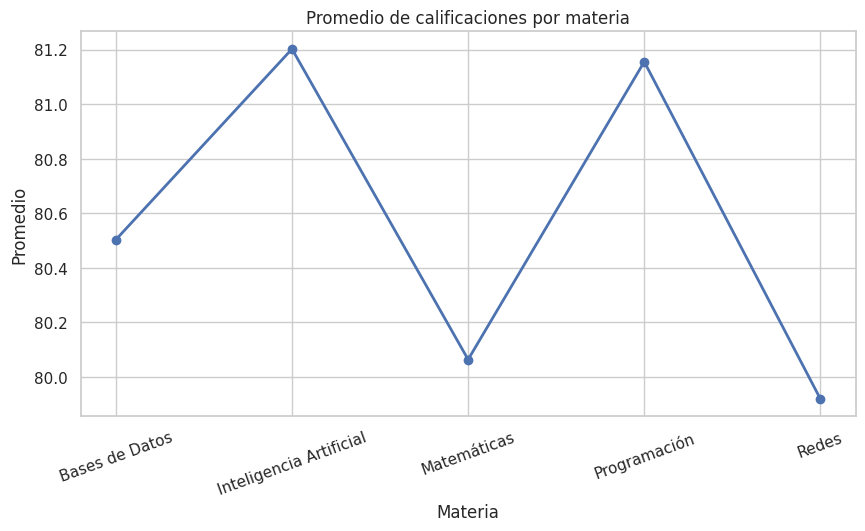

In [ ]:
# PASO 4. MATPLOTLIB
# PROMEDIO DE CALIFICACIÓN POR MATERIA
promedio = df.groupby("Materia")["Calificacion"].mean()

plt.figure(figsize=(10,5))

plt.plot(
    promedio.index,
    promedio.values,
    marker="o",
    linewidth=2
)

plt.title("Promedio de calificaciones por materia")

plt.xlabel("Materia")

plt.ylabel("Promedio")

plt.xticks(rotation=20)

plt.show()

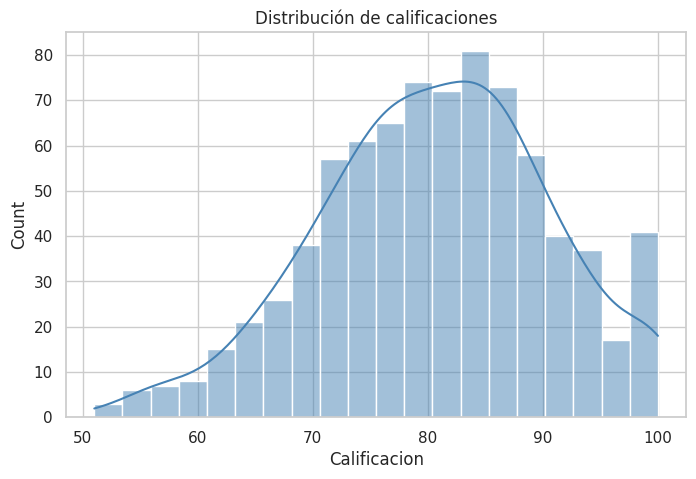

In [ ]:
# PASO 5. SEABORN
# DISTRIBUCIÓN DE CALIFICACIONES
plt.figure(figsize=(8,5))

sns.histplot(
    df["Calificacion"],
    bins=20,
    kde=True,
    color="steelblue"
)

plt.title("Distribución de calificaciones")

plt.show()

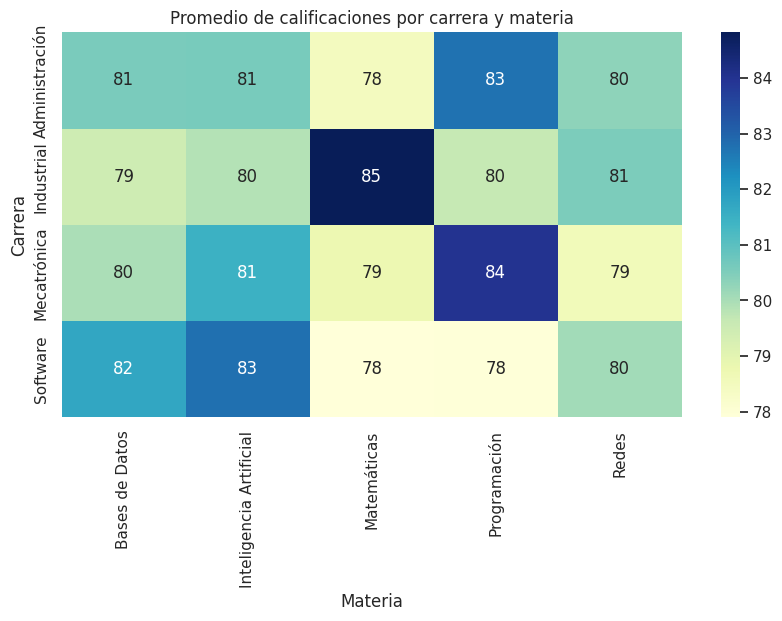

In [ ]:
# PASO 6. SEABORN
# MAPA DE CALOR

# PROMEDIO POR CARRERA Y MATERIA

tabla = df.pivot_table(

    values="Calificacion",

    index="Carrera",

    columns="Materia",

    aggfunc="mean"

)

plt.figure(figsize=(10,5))

sns.heatmap(
    tabla,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Promedio de calificaciones por carrera y materia")

plt.show()

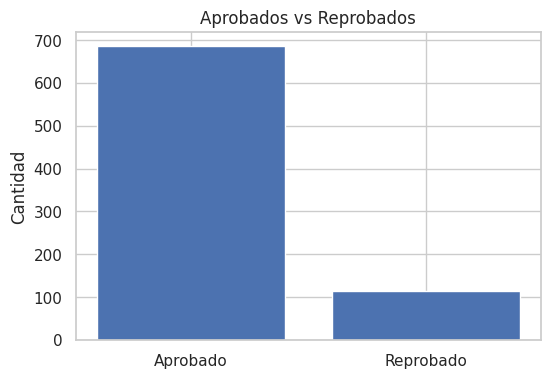

In [ ]:
# PASO 7. MATPLOTLIB
# ESTUDIANTES APROBADOS Y REPROBADOS
estado = df["Estatus"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    estado.index,
    estado.values
)

plt.title("Aprobados vs Reprobados")

plt.ylabel("Cantidad")

plt.show()

In [ ]:
# PASO 8. PLOTLY
# HORAS DE ESTUDIO VS CALIFICACIÓN
fig = px.scatter(

    df,

    x="Horas_Estudio",

    y="Calificacion",

    color="Carrera",

    size="Asistencia",

    hover_data=["Materia","Estatus"]

)

fig.show()

In [ ]:
# PASO 9. PLOTLY
# PROMEDIO POR CARRERA
promedio_carrera = df.groupby("Carrera")["Calificacion"].mean().reset_index()

fig = px.bar(

    promedio_carrera,

    x="Carrera",

    y="Calificacion",

    color="Carrera",

    title="Promedio de calificación por carrera"

)

fig.show()